In [ ]:
from math import prod

classes = ["Spam", "Ham"]  # 클래스
prior = {"Spam": 0.4, "Ham": 0.6}  # 사전 확률 P(C)

# 단어별 우도 P(X|C)
likelihood = {
    "Spam": {"free": 0.7, "urgent": 0.6},
    "Ham": {"free": 0.2, "urgent": 0.1},
}
X = ["free", "urgent"]  # 예측하려는 텍스트의 단어들

scores = {}
for c in classes:
    #### [ 빈칸: 이 부분을 직접 코딩하세요 ]
    # 목표: 텍스트 풀이에서 계산한 P(X|C)*P(C)를 코드로 재현
    px_given_c = prod([likelihood[c][token] for token in X])
    scores[c] = px_given_c * prior[c]

pred = max(scores, key=scores.get)
print("NB scores:", scores)
print("NB prediction:", pred)

NB scores: {'Spam': 0.168, 'Ham': 0.012000000000000002}
NB prediction: Spam


In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
# 훈련 데이터
train_texts = ["free urgent offer", "free free urgent", "meeting schedule", "project discussion"]
labels = ['Spam', 'Spam','Harm','Harm']
# 테스트 -> 숫자
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_texts)
model = MultinomialNB()
model.fit(X_train,labels)
# 예측할 문장
test_text = ['i am free']
X_test =  vectorizer.transform(test_text)
pred = model.predict_proba(X_test)
pred , model.classes_

(array([[0.22807018, 0.77192982]]), array(['Harm', 'Spam'], dtype='<U4'))

In [15]:
print('class prior p(C)')
print(model.class_log_prior_)

print('feature log probality p(word|C)')
print(model.feature_log_prob_)

print('vocabulary')
print(vectorizer.get_feature_names_out())

class prior p(C)
[-0.69314718 -0.69314718]
feature log probality p(word|C)
[[-1.70474809 -2.39789527 -1.70474809 -2.39789527 -1.70474809 -1.70474809
  -2.39789527]
 [-2.56494936 -1.178655   -2.56494936 -1.87180218 -2.56494936 -2.56494936
  -1.46633707]]
vocabulary
['discussion' 'free' 'meeting' 'offer' 'project' 'schedule' 'urgent']


In [21]:
# iris데이터를 가지고 품종 분류
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y, random_state=42)
nb = MultinomialNB()
nb.fit(x_train,y_train)
y_predict = nb.predict(x_test)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



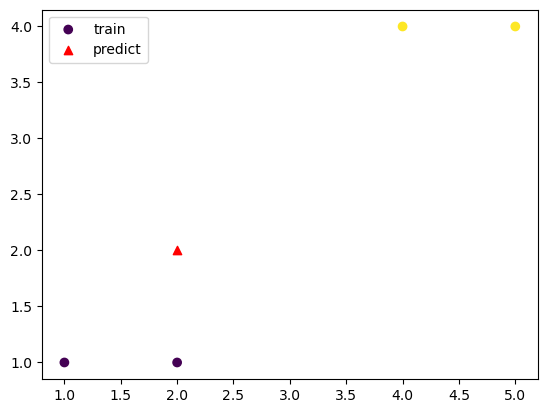

In [29]:
import matplotlib.pyplot as plt
import numpy as np
train_X = np.array([[1, 1], [2, 1], [4, 4], [5, 4]])
train_y = np.array([0, 0, 1, 1])
query = np.array([2, 2])
plt.scatter(train_X[:,0],train_X[:,1],label='train',c=train_y)
plt.scatter(query[0],query[1],label='predict',marker='^',c='red')
plt.legend()
plt.show()

In [47]:
from math import sqrt
from collections import Counter
import numpy as np

train_X = np.array([[1, 1], [2, 1], [4, 4], [5, 4]])
train_y = np.array([0, 0, 1, 1])
query = np.array([2, 2])
k = 3

def euclidean(p, q):
    #### [ 빈칸: 이 부분을 직접 코딩하세요 ]
    # 목표: 텍스트 풀이에서 계산한 sqrt(Σ(p_i - q_i)^2)를 코드로 재현
    return sqrt(sum((p-q)**2))    
    

dists = [ (euclidean(query,x) ,int(y)) for x,y in zip(train_X, train_y )]

dists.sort(key=lambda x : x[0])
knn = [label for _, label in dists[:k]]
pred = Counter(knn).most_common(1)[0][0]

print("k-NN sorted distances:", dists)
print("k-NN neighbors:", knn)
print("k-NN prediction:", pred)

k-NN sorted distances: [(1.0, 0), (1.4142135623730951, 0), (2.8284271247461903, 1), (3.605551275463989, 1)]
k-NN neighbors: [0, 0, 1]
k-NN prediction: 0


In [53]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
iris = load_iris(as_frame=True)
X = iris.data 
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
kgc = KNeighborsClassifier(n_neighbors=20)
kgc.fit(x_train,y_train)
y_predict = kgc.predict(x_test)
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.92      0.92      0.92        13
           2       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



In [55]:
# 최적의 k 찾기
# k=1 ,2,3, ~~ N 
# 각 k의 값에따른 교차검증(cv=5)을 해서 (score, k)  리스트로 저장
# score가 가장 높을때의 k의 값을 출력